In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nirmeetchoudhary/bank-personal-loan-modelling/Bank_Personal_Loan_Modelling.csv


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             classification_report, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

In [16]:
df_loan = pd.read_csv('/kaggle/input/datasets/nirmeetchoudhary/bank-personal-loan-modelling/Bank_Personal_Loan_Modelling.csv')
df_loan.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


## Step 2 — Load & Explore Data

In [17]:
print("Shape:", df_loan.shape)
print("\nColumn Info:")
df_loan.info()

print("\nMissing Values:")
print(df_loan.isnull().sum())

print("\nBasic Stats:")
df_loan.describe()

Shape: (5000, 14)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB

Missing Values:
ID     

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


Personal Loan
0    4520
1     480
Name: count, dtype: int64


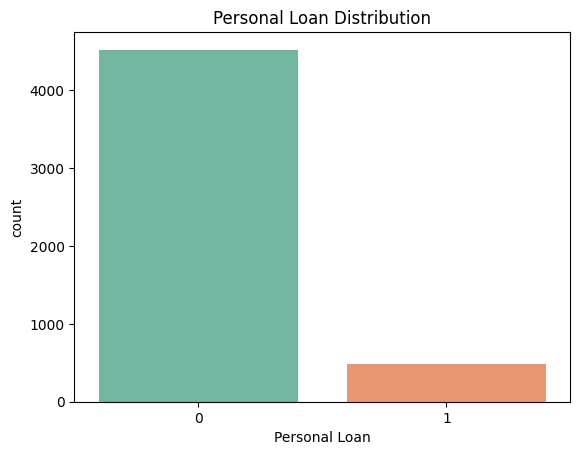

In [18]:
# ✅ Q1: How many people took personal loan?
print(df_loan['Personal Loan'].value_counts())
sns.countplot(x='Personal Loan', data=df_loan, palette='Set2')
plt.title("Personal Loan Distribution")
plt.show()


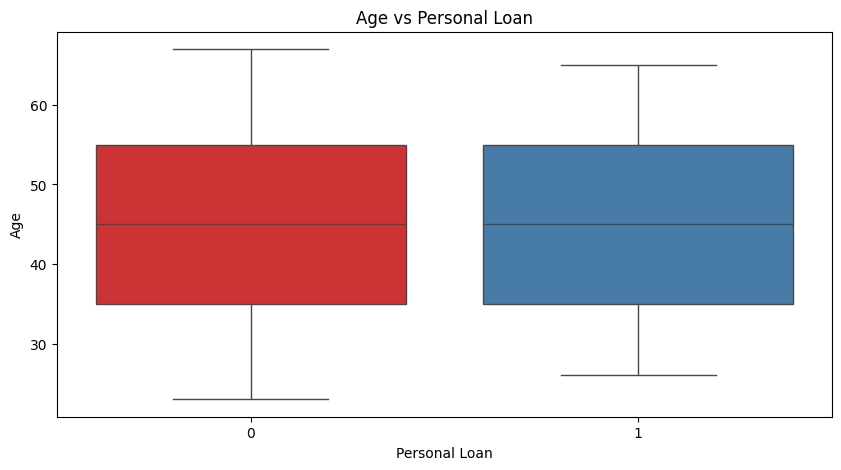

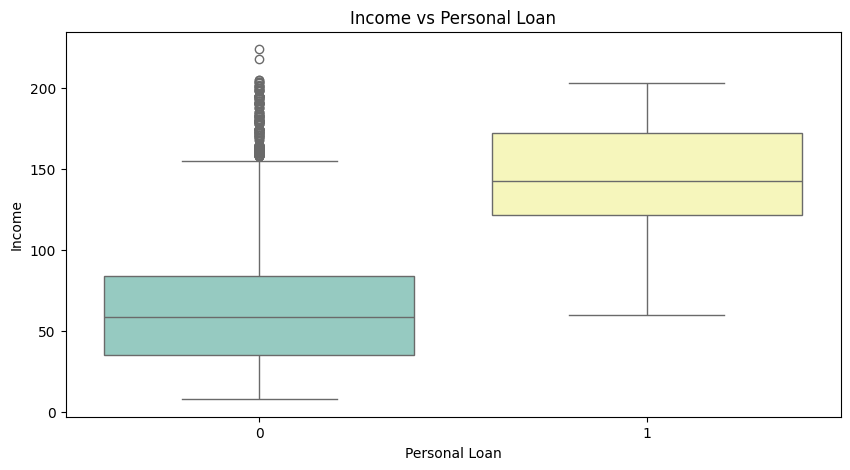

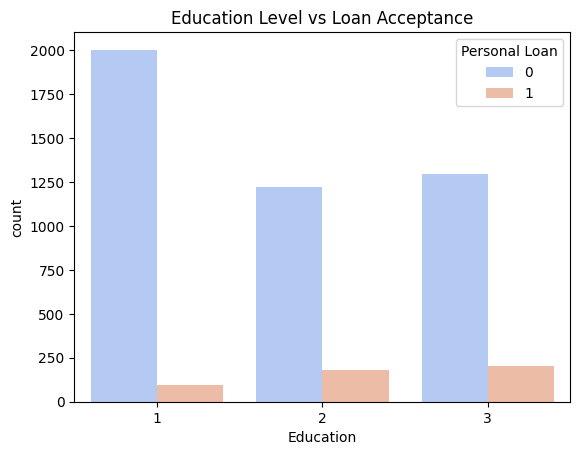

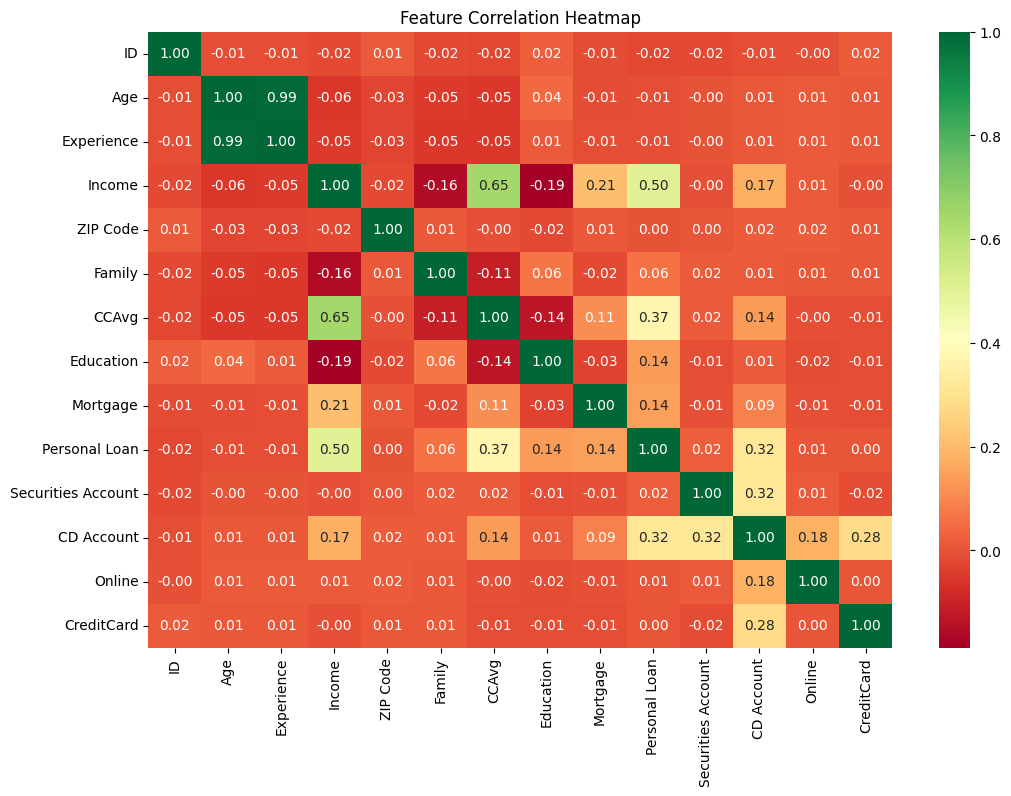

In [19]:

# ✅ Q2: Does Age impact loan buying?
plt.figure(figsize=(10,5))
sns.boxplot(x='Personal Loan', y='Age', data=df_loan, palette='Set1')
plt.title("Age vs Personal Loan")
plt.show()

# ✅ Q3: Do low income people borrow more?
plt.figure(figsize=(10,5))
sns.boxplot(x='Personal Loan', y='Income', data=df_loan, palette='Set3')
plt.title("Income vs Personal Loan")
plt.show()

# ✅ Q4: Education vs Loan
sns.countplot(x='Education', hue='Personal Loan', data=df_loan, palette='coolwarm')
plt.title("Education Level vs Loan Acceptance")
plt.show()

# ✅ Q5: Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_loan.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

#  Model 1: Logistic Regression

=== Logistic Regression ===
Accuracy: 0.952

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97      1343
           1       0.85      0.66      0.74       157

    accuracy                           0.95      1500
   macro avg       0.90      0.82      0.86      1500
weighted avg       0.95      0.95      0.95      1500



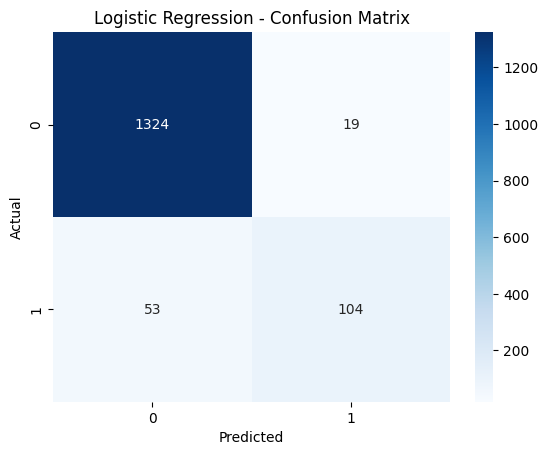

In [29]:
X = df_loan.drop(['ID', 'ZIP Code', 'Personal Loan'], axis=1)
y = df_loan['Personal Loan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model2: Decision tree

=== Decision Tree ===
Accuracy: 0.9826666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1343
           1       0.96      0.87      0.91       157

    accuracy                           0.98      1500
   macro avg       0.97      0.93      0.95      1500
weighted avg       0.98      0.98      0.98      1500



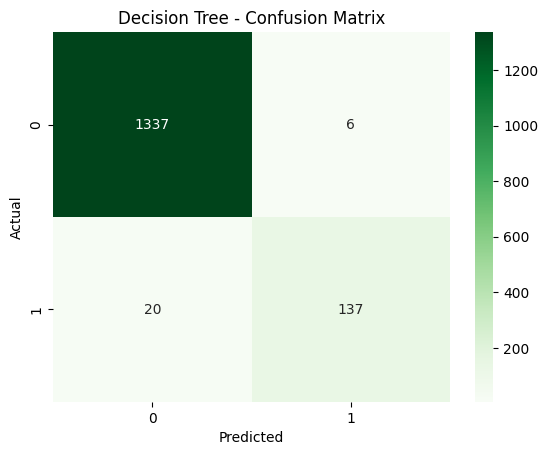

In [30]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#  Feature Importance & ROC Curve

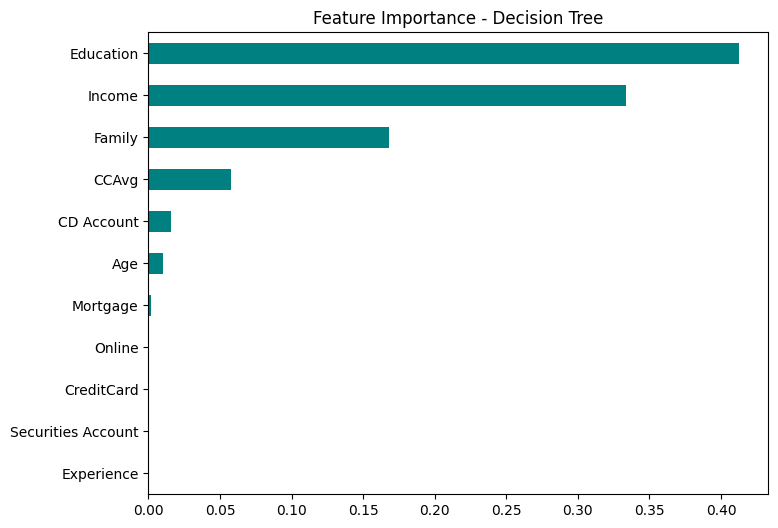

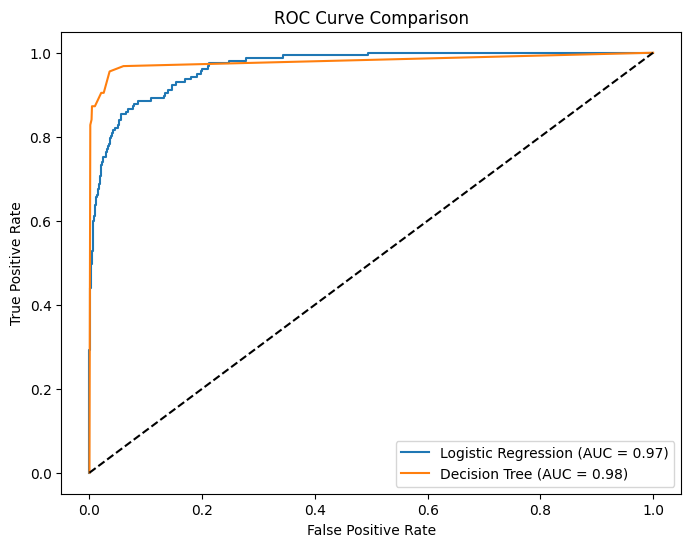

In [31]:
# ✅ Feature Importance (Decision Tree)
feat_imp = pd.Series(dt.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', color='teal', figsize=(8,6))
plt.title("Feature Importance - Decision Tree")
plt.show()

# ✅ ROC Curve Comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_sc)[:,1])
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt.predict_proba(X_test)[:,1])

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1]):.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]):.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [32]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_dt), 4)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1]), 4),
        round(roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]), 4)
    ]
})
print(results)

                 Model  Accuracy  ROC-AUC
0  Logistic Regression    0.9520   0.9667
1        Decision Tree    0.9827   0.9797


#  Save Models with Picklepython

In [27]:
import pickle
import os

# Create a folder to save models
os.makedirs('models', exist_ok=True)

# ✅ Save Logistic Regression Model
with open('models/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr, f)
print("✅ Logistic Regression Model Saved!")

# ✅ Save Decision Tree Model
with open('models/decision_tree_model.pkl', 'wb') as f:
    pickle.dump(dt, f)
print("✅ Decision Tree Model Saved!")

# ✅ Save Scaler (VERY IMPORTANT - needed for Logistic Regression predictions)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler Saved!")

✅ Logistic Regression Model Saved!
✅ Decision Tree Model Saved!
✅ Scaler Saved!


In [28]:
import pickle
import numpy as np

print("=" * 45)
print("   🏦 PERSONAL LOAN PREDICTION TESTER")
print("=" * 45)
print("\nEnter customer details below:\n")

# ✅ Take Input from User
age         = int(input("Age (e.g. 35): "))
experience  = int(input("Experience in years (e.g. 10): "))
income      = int(input("Annual Income in $000 (e.g. 80): "))
family      = int(input("Family size (1-4): "))
ccavg       = float(input("Monthly Credit Card Spend in $000 (e.g. 2.5): "))
education   = int(input("Education (1=Undergrad, 2=Graduate, 3=Advanced): "))
mortgage    = int(input("Mortgage value in $000 (0 if none): "))
securities  = int(input("Securities Account? (0=No, 1=Yes): "))
cd          = int(input("CD Account? (0=No, 1=Yes): "))
online      = int(input("Uses Online Banking? (0=No, 1=Yes): "))
creditcard  = int(input("Has Credit Card? (0=No, 1=Yes): "))

# ✅ Load Models & Scaler
with open('models/logistic_regression_model.pkl', 'rb') as f:
    lr_model = pickle.load(f)

with open('models/decision_tree_model.pkl', 'rb') as f:
    dt_model = pickle.load(f)

with open('models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# ✅ Prepare Input
input_data = np.array([[age, experience, income, family, ccavg,
                        education, mortgage, securities, cd, online, creditcard]])

input_scaled = scaler.transform(input_data)

# ✅ Predictions
lr_pred  = lr_model.predict(input_scaled)[0]
lr_prob  = lr_model.predict_proba(input_scaled)[0][1] * 100

dt_pred  = dt_model.predict(input_data)[0]
dt_prob  = dt_model.predict_proba(input_data)[0][1] * 100

# ✅ Display Result
print("\n" + "=" * 45)
print("           📊 PREDICTION RESULTS")
print("=" * 45)

print(f"\n🔹 Logistic Regression:")
print(f"   Result      : {'✅ Will Take Loan' if lr_pred == 1 else '❌ Will NOT Take Loan'}")
print(f"   Confidence  : {lr_prob:.2f}%")

print(f"\n🔹 Decision Tree:")
print(f"   Result      : {'✅ Will Take Loan' if dt_pred == 1 else '❌ Will NOT Take Loan'}")
print(f"   Confidence  : {dt_prob:.2f}%")

print("\n" + "=" * 45)

if lr_pred == 1 and dt_pred == 1:
    print("🎯 FINAL: HIGH CHANCE — Customer likely to take loan!")
elif lr_pred == 0 and dt_pred == 0:
    print("🎯 FINAL: LOW CHANCE — Customer unlikely to take loan.")
else:
    print("🎯 FINAL: UNCERTAIN — Models disagree, borderline case.")

print("=" * 45)

   🏦 PERSONAL LOAN PREDICTION TESTER

Enter customer details below:



Age (e.g. 35):  45
Experience in years (e.g. 10):  19
Annual Income in $000 (e.g. 80):  11
Family size (1-4):  9004
Monthly Credit Card Spend in $000 (e.g. 2.5):  120
Education (1=Undergrad, 2=Graduate, 3=Advanced):  2
Mortgage value in $000 (0 if none):  200
Securities Account? (0=No, 1=Yes):  0
CD Account? (0=No, 1=Yes):  1
Uses Online Banking? (0=No, 1=Yes):  1
Has Credit Card? (0=No, 1=Yes):  0



           📊 PREDICTION RESULTS

🔹 Logistic Regression:
   Result      : ✅ Will Take Loan
   Confidence  : 100.00%

🔹 Decision Tree:
   Result      : ✅ Will Take Loan
   Confidence  : 100.00%

🎯 FINAL: HIGH CHANCE — Customer likely to take loan!
